# DATASET GENERATION


In [1]:
import pandas as pd
import numpy as np
import time
import os

# --- 0. DEFINE THE SAVE DIRECTORY ---
save_dir = '/content/CAPSTONE_PROJECT'
output_file_path = os.path.join(save_dir, 'balanced_dataset.csv')

# --- 1. DEFINE THE SCORING RUBRIC AND THRESHOLDS (Unchanged) ---
scoring_rubric = {
    'Q1': {'(a) Under 35': 5, '(b) 36-45': 4, '(c) 46-59': 3, '(d) 60-70': 2, '(e) Over 70': 1},
    'Q2': {'(a) Less than $50,000': 1, '(b) $50,000 - $99,999': 2, '(c) $100,000 - $199,999': 3, '(d) More than $200,000': 4},
    'Q3': {'(a) Less than $50,000': 1, '(b) $50,000 - $249,999': 2, '(c) $250,000 - $999,999': 3, '(d) $1,000,000 or more': 4},
    'Q4': {'(a) Retirement': 4, '(b) Major Purchase': 2, '(c) General Wealth Growth': 5, '(d) Generating Income': 1},
    'Q5': {'(a) Less than 4 years': 1, '(b) 4-10 years': 2, '(c) 11-20 years': 3, '(d) More than 20 years': 4},
    'Q6': {'(a) Very Inexperienced': 1, '(b) Somewhat Inexperienced': 2, '(c) Experienced': 3, '(d) Very Experienced': 4},
    'Q7': {'(a) Very stable': 3, '(b) Moderately stable': 2, '(c) Uncertain / High risk': 1},
    'Q8': {'(a) Very important': 1, '(b) Moderately important': 2, '(c) Not important': 3},
    'Q9': {'(a) Loss': 1, '(b) Uncertainty': 2, '(c) Opportunity': 3, '(d) Thrill': 4},
    'Q10': {'(a) Sell all': 1, '(b) Sell some': 2, '(c) Hold and do nothing': 3, '(d) Buy more': 4},
    'Q11': {'(a) $1,000 in cash': 1, '(b) A 50% chance of winning $5,000': 2, '(c) A 25% chance of winning $10,000': 3, '(d) A 5% chance of winning $100,000': 4},
    'Q12': {'(a) $200 gain / $0 loss': 1, '(b) $800 gain / $200 loss': 2, '(c) $2,600 gain / $800 loss': 3, '(d) $4,800 gain / $2,400 loss': 4}
}

def get_risk_profile(score):
    if 12 <= score <= 23: return 'Conservative'
    elif 24 <= score <= 35: return 'Moderate'
    else: return 'Aggressive'

# --- 2. DEFINE PROBABILITY CONFIGS FOR EACH PROFILE TYPE ---
configs = {
    'Conservative': {
        'Q1': {'p': [0.05, 0.1, 0.2, 0.3, 0.35]}, 'Q2': {'p': [0.5, 0.3, 0.15, 0.05]},
        'Q3': {'p': [0.5, 0.3, 0.15, 0.05]}, 'Q4': {'p': [0.1, 0.2, 0.2, 0.5]},
        'Q5': {'p': [0.4, 0.3, 0.2, 0.1]}, 'Q6': {'p': [0.5, 0.4, 0.1, 0.0]},
        'Q7': {'p': [0.1, 0.3, 0.6]}, 'Q8': {'p': [0.6, 0.3, 0.1]},
        'Q9': {'p': [0.6, 0.3, 0.1, 0.0]}, 'Q10': {'p': [0.5, 0.4, 0.1, 0.0]},
        'Q11': {'p': [0.7, 0.2, 0.1, 0.0]}, 'Q12': {'p': [0.7, 0.2, 0.1, 0.0]}
    },
    'Moderate': {
        'Q1': {'p': [0.25, 0.25, 0.25, 0.15, 0.10]}, 'Q2': {'p': [0.25, 0.35, 0.25, 0.15]},
        'Q3': {'p': [0.30, 0.35, 0.25, 0.10]}, 'Q4': {'p': [0.40, 0.15, 0.40, 0.05]},
        'Q5': {'p': [0.10, 0.20, 0.30, 0.40]}, 'Q6': {'p': [0.30, 0.40, 0.25, 0.05]},
        'Q7': {'p': [0.40, 0.50, 0.10]}, 'Q8': {'p': [0.15, 0.35, 0.50]},
        'Q9': {'p': [0.30, 0.40, 0.25, 0.05]}, 'Q10': {'p': [0.15, 0.20, 0.50, 0.15]},
        'Q11': {'p': [0.20, 0.40, 0.30, 0.10]}, 'Q12': {'p': [0.20, 0.40, 0.30, 0.10]}
    },
    'Aggressive': {
        'Q1': {'p': [0.4, 0.3, 0.2, 0.1, 0.0]}, 'Q2': {'p': [0.1, 0.2, 0.3, 0.4]},
        'Q3': {'p': [0.1, 0.2, 0.3, 0.4]}, 'Q4': {'p': [0.1, 0.1, 0.7, 0.1]},
        'Q5': {'p': [0.0, 0.1, 0.3, 0.6]}, 'Q6': {'p': [0.0, 0.1, 0.4, 0.5]},
        'Q7': {'p': [0.7, 0.2, 0.1]}, 'Q8': {'p': [0.1, 0.2, 0.7]},
        'Q9': {'p': [0.0, 0.1, 0.4, 0.5]}, 'Q10': {'p': [0.0, 0.1, 0.4, 0.5]},
        'Q11': {'p': [0.0, 0.1, 0.4, 0.5]}, 'Q12': {'p': [0.0, 0.1, 0.4, 0.5]}
    }
}

# --- 3. OPTIMIZED GENERATION FUNCTION ---
def generate_specific_profile(profile_type):
    while True:
        profile = {}
        total_score = 0
        config = configs[profile_type]
        for q_id in range(1, 13):
            question_key = f'Q{q_id}'
            answers = list(scoring_rubric[question_key].keys())
            probabilities = config[question_key]['p']
            chosen_answer = np.random.choice(answers, p=probabilities)
            profile[question_key] = chosen_answer
            total_score += scoring_rubric[question_key][chosen_answer]
        profile['Total_Score'] = total_score
        profile['Risk_Profile'] = get_risk_profile(total_score)
        if profile['Risk_Profile'] == profile_type:
            return profile

# --- 4. GENERATE THE BALANCED DATASET ---
start_time = time.time()
target_counts = {'Conservative': 6000, 'Moderate': 8000, 'Aggressive': 6000}
all_profiles = []

for profile_type, count in target_counts.items():
    print(f"Generating {count} '{profile_type}' profiles...")
    for _ in range(count):
        all_profiles.append(generate_specific_profile(profile_type))

# --- 5. CREATE AND SAVE THE DATAFRAME ---
df = pd.DataFrame(all_profiles)
df = df.sample(frac=1).reset_index(drop=True) # Shuffle the dataset
column_order = [f'Q{i}' for i in range(1, 13)] + ['Total_Score', 'Risk_Profile']
df = df[column_order]

# Ensure the directory exists before saving
os.makedirs(save_dir, exist_ok=True)
df.to_csv(output_file_path, index=False)

end_time = time.time()
print(f"\nSuccessfully generated {len(df)} BALANCED synthetic profiles in {end_time - start_time:.2f} seconds.")
print(f"Dataset saved to '{output_file_path}'")
print("\nNew distribution of risk profiles:")
print(df['Risk_Profile'].value_counts(normalize=True).map('{:.2%}'.format))

Generating 6000 'Conservative' profiles...
Generating 8000 'Moderate' profiles...
Generating 6000 'Aggressive' profiles...

Successfully generated 20000 BALANCED synthetic profiles in 19.62 seconds.
Dataset saved to '/content/CAPSTONE_PROJECT/balanced_dataset.csv'

New distribution of risk profiles:
Risk_Profile
Moderate        40.00%
Aggressive      30.00%
Conservative    30.00%
Name: proportion, dtype: object


## EDA


Dataset loaded successfully.

--- 1. DATASET OVERVIEW ---
The dataset contains (20000, 14) rows and 14 columns.

First 5 rows of the dataset:
             Q1                       Q2                       Q3  \
0     (c) 46-59   (d) More than $200,000    (a) Less than $50,000   
1  (a) Under 35    (a) Less than $50,000    (a) Less than $50,000   
2  (a) Under 35  (c) $100,000 - $199,999  (c) $250,000 - $999,999   
3   (e) Over 70    (b) $50,000 - $99,999  (c) $250,000 - $999,999   
4     (b) 36-45    (b) $50,000 - $99,999    (a) Less than $50,000   

                          Q4                      Q5  \
0  (c) General Wealth Growth  (d) More than 20 years   
1      (d) Generating Income         (c) 11-20 years   
2  (c) General Wealth Growth         (c) 11-20 years   
3      (d) Generating Income          (b) 4-10 years   
4  (c) General Wealth Growth          (b) 4-10 years   

                           Q6                         Q7  \
0  (b) Somewhat Inexperienced            (a) V

/tmp/ipython-input-3147447455.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Risk_Profile', data=df, order=['Conservative', 'Moderate', 'Aggressive'], palette='viridis')


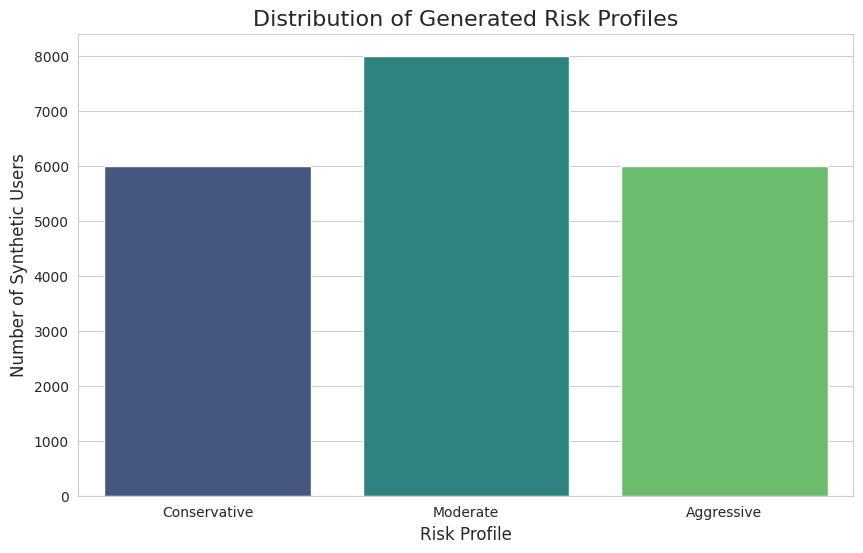


Percentage distribution of risk profiles:
Risk_Profile
Moderate        40.00%
Aggressive      30.00%
Conservative    30.00%
Name: proportion, dtype: object

--- 3. EXPLORING KEY USER CHARACTERISTICS ---


/tmp/ipython-input-3147447455.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0,0], y='Q1', data=df, order=sorted(df['Q1'].unique()), palette='Blues_d')
/tmp/ipython-input-3147447455.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0,1], y='Q3', data=df, order=sorted(df['Q3'].unique()), palette='Greens_d')
/tmp/ipython-input-3147447455.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[1,0], y='Q10', data=df, order=df['Q10'].value_counts(ascending=True).index, palette='Reds_d')
/tmp/ipython-input-3147

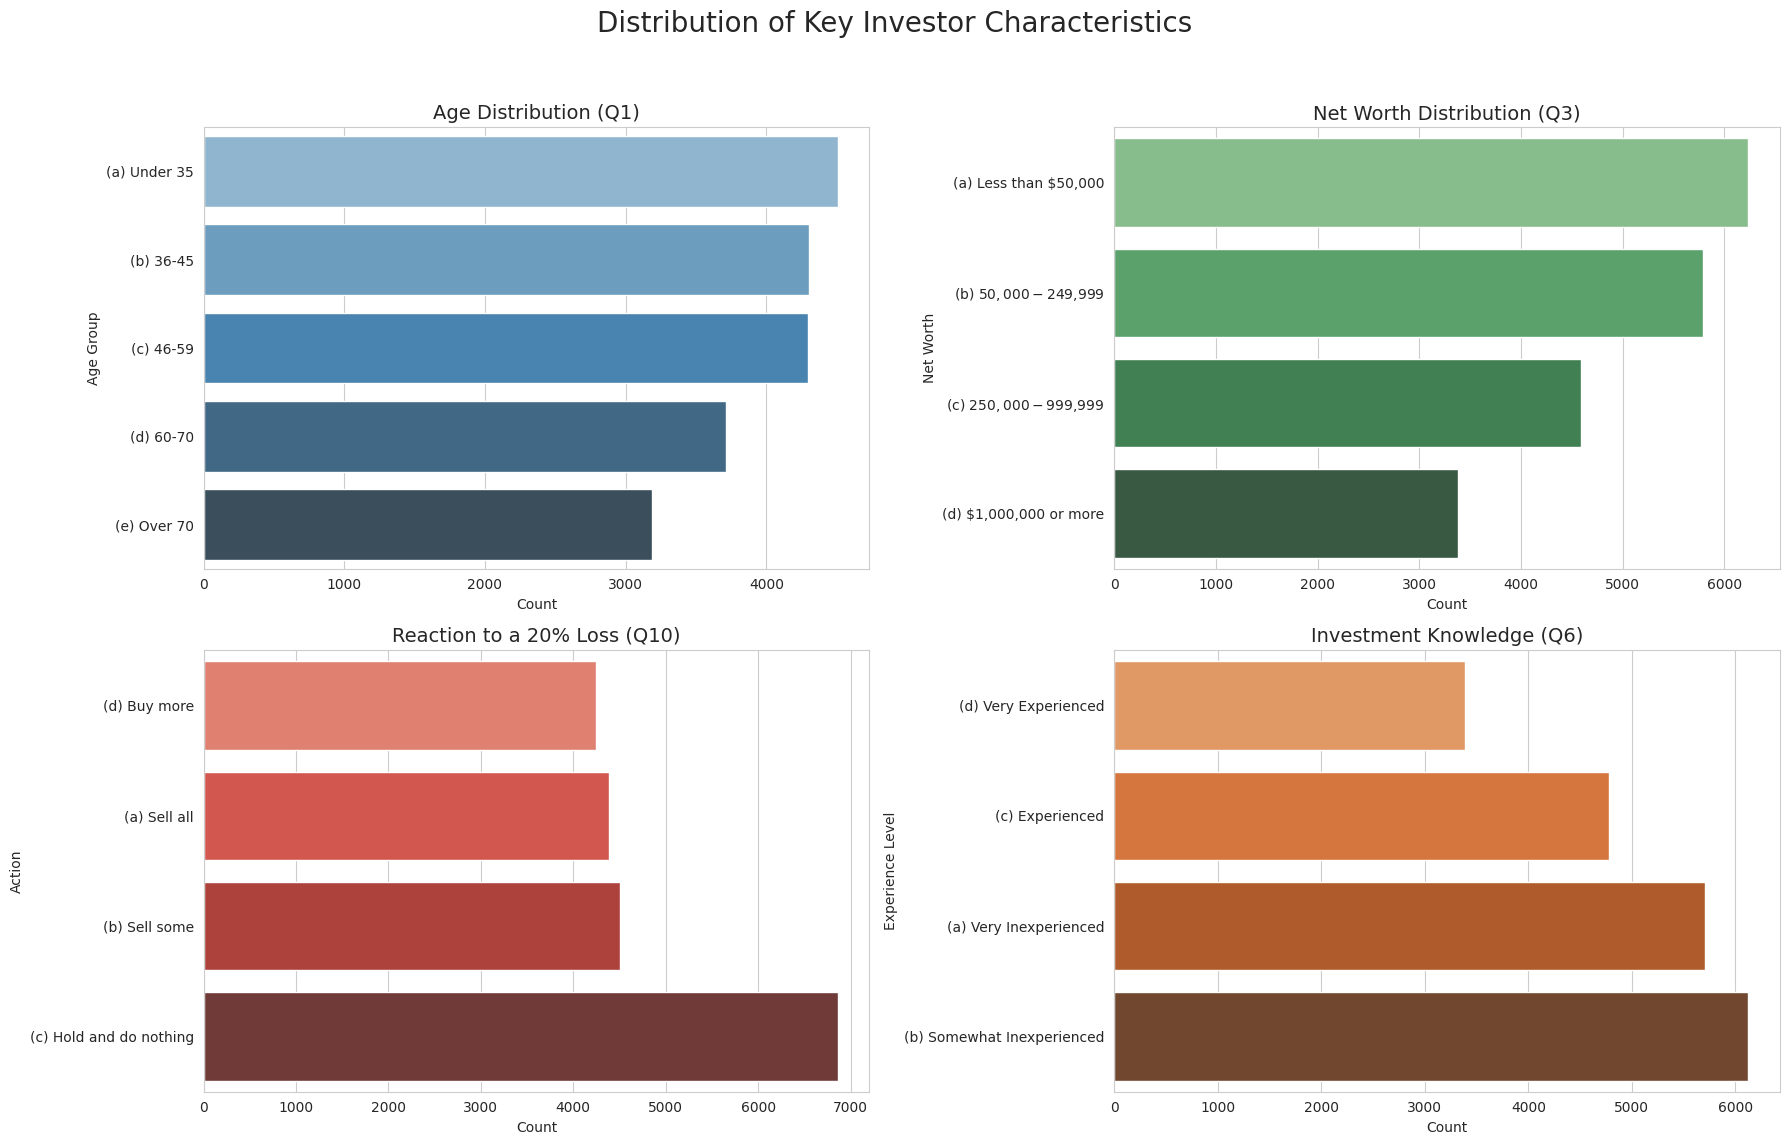


--- 4. INITIAL INSIGHTS: RELATIONSHIPS WITH RISK PROFILE ---


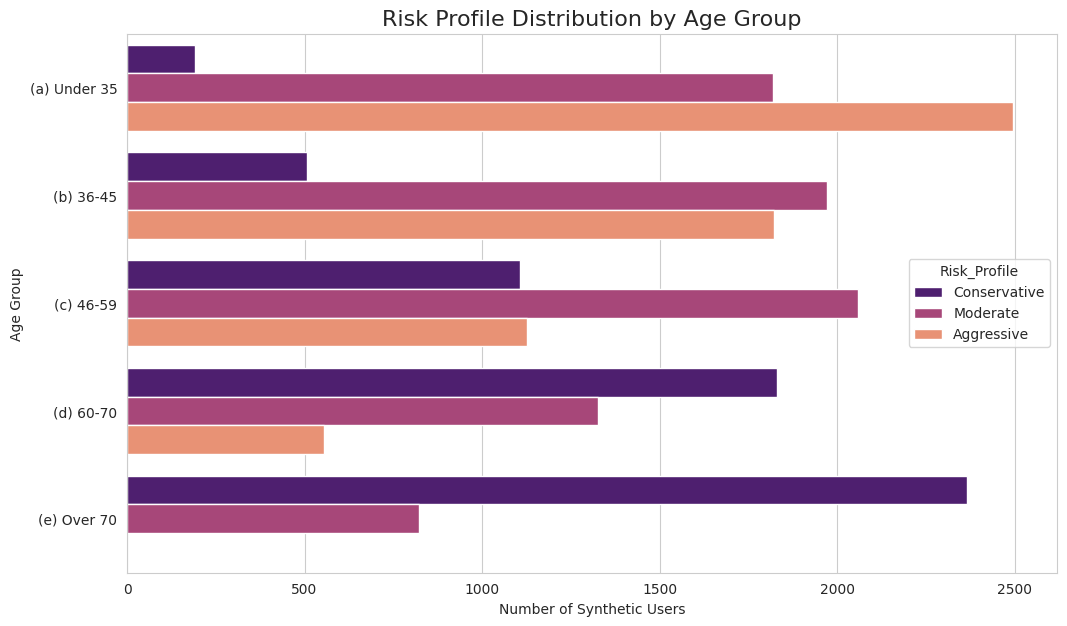

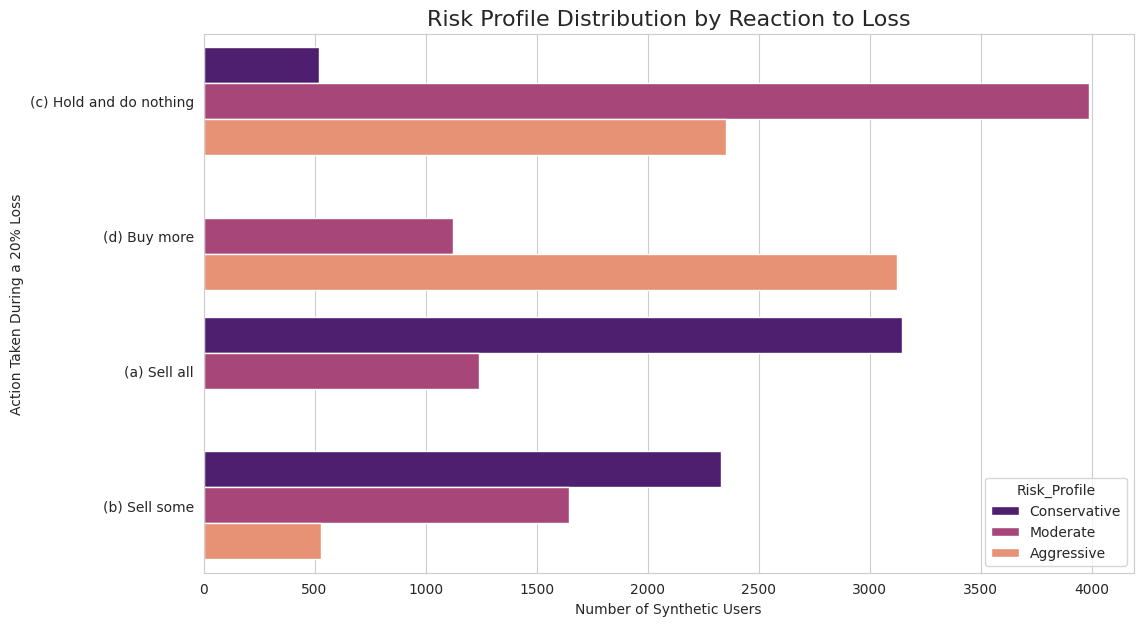

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Update this path if you saved the file in a different folder
file_path = '/content/CAPSTONE_PROJECT/balanced_dataset.csv'
try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
    print("Please make sure the file path is correct.")
    exit()

# Set plot style for better visuals
sns.set_style("whitegrid")

# --- 1. Initial Inspection: Get a feel for the data ---
print("\n--- 1. DATASET OVERVIEW ---")
print(f"The dataset contains {df.shape} rows and {df.shape[1]} columns.")
print("\nFirst 5 rows of the dataset:")
print(df.head())
print("\nData types and non-null values:")
df.info()


# --- 2. Analyze the Target Variable: The Risk Profiles ---
print("\n--- 2. ANALYSIS OF RISK PROFILES ---")
plt.figure(figsize=(10, 6))
sns.countplot(x='Risk_Profile', data=df, order=['Conservative', 'Moderate', 'Aggressive'], palette='viridis')
plt.title('Distribution of Generated Risk Profiles', fontsize=16)
plt.xlabel('Risk Profile', fontsize=12)
plt.ylabel('Number of Synthetic Users', fontsize=12)
plt.show()

# Display the exact percentages
print("\nPercentage distribution of risk profiles:")
print(df['Risk_Profile'].value_counts(normalize=True).map('{:.2%}'.format))


# --- 3. Explore Key Feature Distributions ---
print("\n--- 3. EXPLORING KEY USER CHARACTERISTICS ---")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Distribution of Key Investor Characteristics', fontsize=20)

# Age Distribution (Q1)
sns.countplot(ax=axes[0,0], y='Q1', data=df, order=sorted(df['Q1'].unique()), palette='Blues_d')
axes[0,0].set_title('Age Distribution (Q1)', fontsize=14)
axes[0,0].set_xlabel('Count')
axes[0,0].set_ylabel('Age Group')

# Net Worth Distribution (Q3)
sns.countplot(ax=axes[0,1], y='Q3', data=df, order=sorted(df['Q3'].unique()), palette='Greens_d')
axes[0,1].set_title('Net Worth Distribution (Q3)', fontsize=14)
axes[0,1].set_xlabel('Count')
axes[0,1].set_ylabel('Net Worth')

# Reaction to Loss (Q10)
sns.countplot(ax=axes[1,0], y='Q10', data=df, order=df['Q10'].value_counts(ascending=True).index, palette='Reds_d')
axes[1,0].set_title('Reaction to a 20% Loss (Q10)', fontsize=14)
axes[1,0].set_xlabel('Count')
axes[1,0].set_ylabel('Action')

# Investment Knowledge (Q6)
sns.countplot(ax=axes[1, 1], y='Q6', data=df, order=df['Q6'].value_counts(ascending=True).index, palette='Oranges_d')
axes[1, 1].set_title('Investment Knowledge (Q6)', fontsize=14)
axes[1, 1].set_xlabel('Count')
axes[1, 1].set_ylabel('Experience Level')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# --- 4. Find Initial Insights: How do features relate to the risk profile? ---
print("\n--- 4. INITIAL INSIGHTS: RELATIONSHIPS WITH RISK PROFILE ---")

# How does Age relate to Risk Profile?
plt.figure(figsize=(12, 7))
sns.countplot(y='Q1', hue='Risk_Profile', data=df, order=sorted(df['Q1'].unique()), hue_order=['Conservative', 'Moderate', 'Aggressive'], palette='magma')
plt.title('Risk Profile Distribution by Age Group', fontsize=16)
plt.xlabel('Number of Synthetic Users')
plt.ylabel('Age Group')
plt.show()

# How does Reaction to Loss relate to Risk Profile?
plt.figure(figsize=(12, 7))
sns.countplot(y='Q10', hue='Risk_Profile', data=df, hue_order=['Conservative', 'Moderate', 'Aggressive'], palette='magma')
plt.title('Risk Profile Distribution by Reaction to Loss', fontsize=16)
plt.xlabel('Number of Synthetic Users')
plt.ylabel('Action Taken During a 20% Loss')
plt.show()

Dataset loaded successfully.

Training Random Forest Classifier...

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

  Aggressive       1.00      1.00      1.00      1241
Conservative       1.00      1.00      1.00      1211
    Moderate       1.00      1.00      1.00      1548

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000


--- CONFUSION MATRIX ---


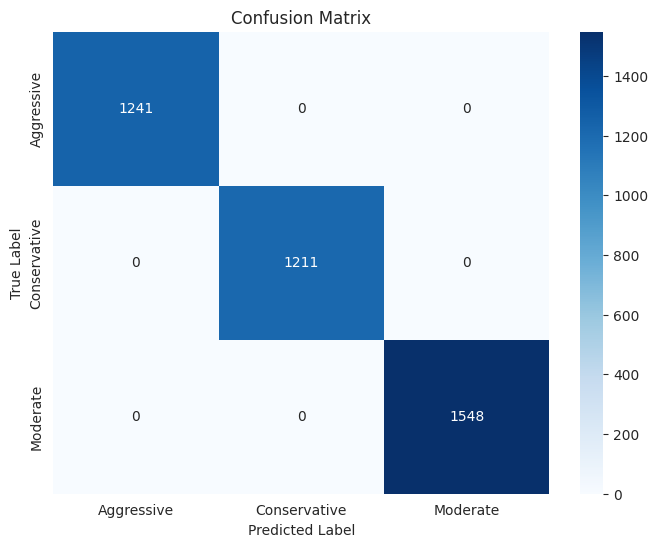


Generating Learning Curves...


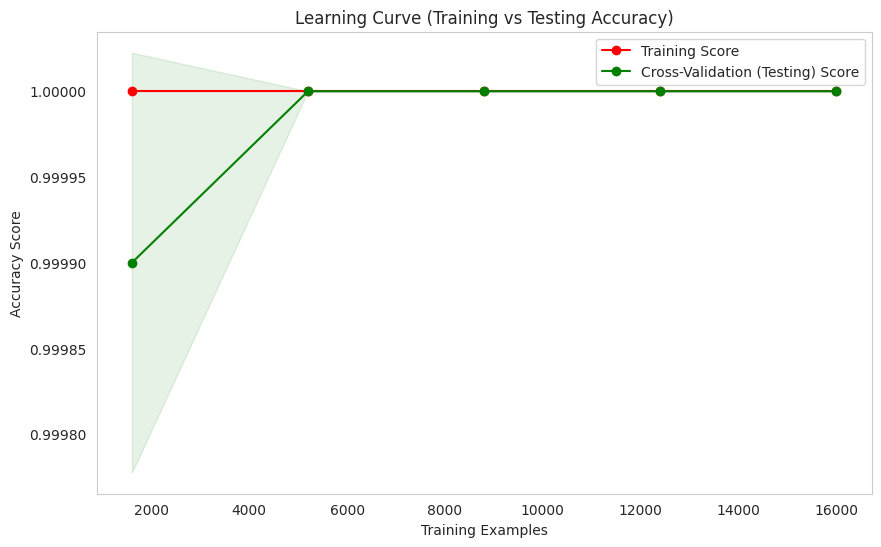


Generating ROC Curves...


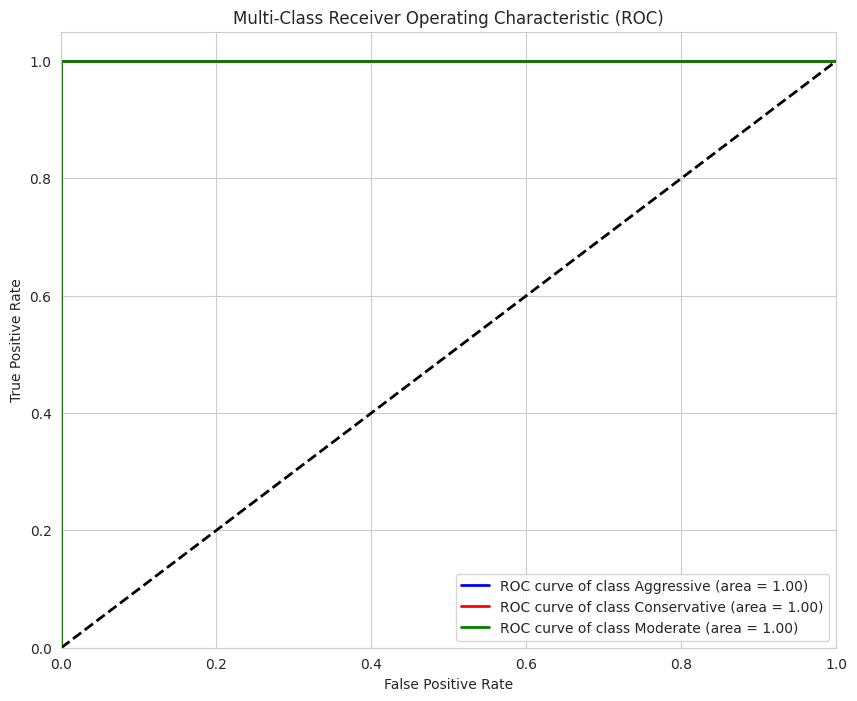


All evaluation plots saved to Google Drive.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from itertools import cycle

# --- 1. SETUP & DATA LOADING ---
# Assumes drive is already mounted from your previous cell
file_path = '/content/CAPSTONE_PROJECT/balanced_dataset.csv'

try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
    exit()

# --- 2. PREPROCESSING ---
# Separate Features (X) and Target (y)
# Assuming 'Risk_Profile' is the target and all other columns are features
X = df.drop('Risk_Profile', axis=1)
y = df['Risk_Profile']

# Encode Categorical Features (Convert text answers to numbers)
# We use LabelEncoder for the target and Dummy variables for features if they are strings
le = LabelEncoder()
y_encoded = le.fit_transform(y) # Converts Conservative/Moderate/Aggressive to 0, 1, 2
class_names = le.classes_

# Handle categorical features (if X contains text strings like 'High', 'Low')
X_encoded = pd.get_dummies(X, drop_first=True)

# Split the data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

# --- 3. TRAIN THE MODEL ---
# Using Random Forest as per your research paper
print("\nTraining Random Forest Classifier...")
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_score = clf.predict_proba(X_test) # Probabilities required for ROC

# --- 4. GENERATE CLASSIFICATION REPORT ---
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred, target_names=class_names))

# --- 5. GENERATE CONFUSION MATRIX ---
print("\n--- CONFUSION MATRIX ---")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.savefig('/content/CAPSTONE_PROJECT/fig_confusion_matrix.png', dpi=300)
plt.show()

# --- 6. GENERATE TRAINING/TESTING CURVES (Learning Curve) ---
# This shows if the model is overfitting or underfitting
print("\nGenerating Learning Curves...")

train_sizes, train_scores, test_scores = learning_curve(
    clf, X_encoded, y_encoded, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
)

# Calculate mean and standard deviation for plotting
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.title("Learning Curve (Training vs Testing Accuracy)")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.grid()

# Plot the shaded area (standard deviation)
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")

# Plot the lines
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training Score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-Validation (Testing) Score")

plt.legend(loc="best")
plt.savefig('/content/CAPSTONE_PROJECT/fig_learning_curve.png', dpi=300)
plt.show()

# --- 7. GENERATE ROC / AUC CURVE (Multi-Class) ---
print("\nGenerating ROC Curves...")

# Binarize the output for One-vs-Rest ROC calculation
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(class_names[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.savefig('/content/CAPSTONE_PROJECT/fig_roc_curve.png', dpi=300)
plt.show()

print("\nAll evaluation plots saved to Google Drive.")

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
import os

# --- 1. LOAD THE BALANCED DATASET ---
# Use the path to your organized project folder
file_path = '/content/drive/My Drive/CAPSTONE_PROJECT/balanced_dataset.csv'
try:
    df = pd.read_csv(file_path)
    print("Balanced dataset loaded successfully.")
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
    print("Please make sure the file path is correct and your Google Drive is mounted.")
    exit() # Stop execution if the file isn't found


# --- 2. PREPARE THE DATA FOR THE MODEL ---
# Define the features (the 12 questions) and the target (the risk profile)
# We will drop the 'Total_Score' column as we want the model to learn from the answers, not the score.
features = [f'Q{i}' for i in range(1, 13)]
target = 'Risk_Profile'

X = df[features]
y = df[target]

# Create a preprocessor to handle the categorical text data
# OneHotEncoder converts text categories into a numerical format the model can understand
categorical_transformer = OneHotEncoder(handle_unknown='ignore')
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, features)
    ])

# --- 3. SPLIT THE DATA INTO TRAINING AND TESTING SETS ---
# 80% for training, 20% for testing. 'stratify=y' ensures both sets have a similar mix of profiles.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Data split into {len(X_train)} training samples and {len(X_test)} testing samples.")


# --- 4. DEFINE AND TRAIN THE MODEL ---
# We create a 'pipeline' that first preprocesses the data and then trains the classifier.
# This is a best practice in machine learning.
model = Pipeline(steps=[('preprocessor', preprocessor),
                      ('classifier', RandomForestClassifier(random_state=42))])

print("\nTraining the Random Forest model...")
model.fit(X_train, y_train)
print("Model training complete.")


# --- 5. EVALUATE THE MODEL ON THE UNSEEN TEST DATA ---
print("\nEvaluating model performance on the test set...")
y_pred = model.predict(X_test)

# Print the performance results
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"\n-----------------------------------")
print(f"  MODEL PERFORMANCE REPORT")
print(f"-----------------------------------")
print(f"\nOverall Accuracy: {accuracy:.4f} ({accuracy:.2%})")
print("\nDetailed Classification Report:")
print(report)

Balanced dataset loaded successfully.
Data split into 16000 training samples and 4000 testing samples.

Training the Random Forest model...
Model training complete.

Evaluating model performance on the test set...

-----------------------------------
  MODEL PERFORMANCE REPORT
-----------------------------------

Overall Accuracy: 0.9805 (98.05%)

Detailed Classification Report:
              precision    recall  f1-score   support

  Aggressive       0.98      0.99      0.99      1231
Conservative       0.98      0.98      0.98      1173
    Moderate       0.98      0.97      0.98      1596

    accuracy                           0.98      4000
   macro avg       0.98      0.98      0.98      4000
weighted avg       0.98      0.98      0.98      4000





# RECOMMENDATION SYSTEM





ALPHAVANTAGE SUPPORT api key  -  IGL0FRLTWJ1OI1EX

In [ ]:
import pandas as pd
import pandas_datareader.data as web
import os
import time

# --- 1. SETUP: DEFINE YOUR PARAMETERS ---
# Define the save directory and the full path for the new file
save_dir = '/content/drive/My Drive/CAPSTONE_PROJECT'
output_file_path = os.path.join(save_dir, 'etf_historical_data.csv')

# Define the tickers for your asset universe
tickers = []

# Define the start and end dates for the historical data
start_date = '2014-01-01'
end_date = '2024-01-01'

all_data = {}
print("Starting historical data download from Stooq...")

# --- 2. DOWNLOAD DATA FOR EACH TICKER ---
for ticker in tickers:
    try:
        print(f"Fetching data for {ticker}...")
        # Use pandas_datareader to get data from the 'stooq' source
        df_ticker = web.DataReader(ticker, 'stooq', start=start_date, end=end_date)

        if df_ticker.empty:
            print(f"  WARNING: No data returned for {ticker}.")
        else:
            # Stooq returns data in descending order, so we sort it to be chronological
            df_ticker = df_ticker.sort_index()
            all_data[ticker] = df_ticker['Close']
            print(f"  Successfully downloaded {len(df_ticker)} rows of data for {ticker}.")

        time.sleep(1) # Be polite to the server

    except Exception as e:
        print(f"  An error occurred while fetching {ticker}: {e}")
        all_data = {} # Clear data if any ticker fails
        break

# --- 3. COMBINE, PROCESS, AND SAVE THE DATA ---
if all_data:
    # Combine all the successful downloads into a single DataFrame
    final_df = pd.DataFrame(all_data)

    # Ensure the project directory exists
    os.makedirs(save_dir, exist_ok=True)

    # Save the complete DataFrame to a CSV file in your Google Drive
    final_df.to_csv(output_file_path)

    print(f"\nSUCCESS: Successfully downloaded and created the data file with {len(final_df)} rows!")
    print(f"Data saved to: {output_file_path}")

    print("\nFirst 5 rows of your new dataset:")
    print(final_df.head())

    print("\nLast 5 rows of your new dataset:")
    print(final_df.tail())
else:
    print("\nCould not download data for all tickers. The process was stopped.")

Starting historical data download from Stooq...

Could not download data for all tickers. The process was stopped.
